In [7]:
%cd 
%cd dev1/scaling-laws-ecnn
%load_ext autoreload
%autoreload 2

import wandb
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import training.utils as utils


/home/frischs
/home/frischs/dev1/scaling-laws-ecnn
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def extract_info_from_log(run):
    file = run.file('output.log')
    file.download(replace=True)

    with open(file.name, "r") as log_file:
        console_logs = log_file.read()
        #print(console_logs)
        
        # Define a regular expression pattern to capture both epoch and learning rate
        pattern = r'Epoch (\d+): reducing learning rate of group \d+ to (\d+\.\d+e[-+]?\d+).'
        
        # Find all matches of the pattern in the content
        matches = re.findall(pattern, console_logs)
        
    os.remove("output.log")

    epochs = [int(epoch) for epoch, _ in matches]
    lrs = [float(lr) for _, lr in matches]

    return epochs, lrs

In [9]:
api = wandb.Api()

filters = {
    "config.model._target_": "networks.eq_nasnet.eq_nasnet.EquivariantNASNet",
    "config.training.epochs": 120,
    "state": "finished",

}

runs = api.runs(path=f"ga92xug/SL-Scaling", filters=filters)


info = {}
for run in runs:
    info[run.id] = {}
    epochs, lr_rates = extract_info_from_log(run)

    info[run.id]["epochs"] = epochs
    info[run.id]["lr_rates"] = lr_rates
    info[run.id]["valid_acc_weighted"] = run.history(keys=["valid.acc_weighted"]).values[:, 1]
    info[run.id]["name"] = run.name

    

df = pd.DataFrame.from_dict(info, orient="index")
df
#print(info)

,epochs,lr_rates,valid_acc_weighted,name
zufkjx7q,"[61, 72, 89, 100, 114]","[0.0025, 0.00125, 0.000625, 0.0003125, 0.00015...","[0.25144726037979126, 0.25835907459259033, 0.2...",b4_d1.4_w1.5_r128
ldduz4hp,"[41, 58, 74, 88, 99, 110]","[0.0025, 0.00125, 0.000625, 0.0003125, 0.00015...","[0.26269465684890747, 0.285726398229599, 0.350...",b4_d1_w1.5_r128
qw5q9gns,"[73, 88, 105]","[0.0025, 0.00125, 0.000625]","[0.25372523069381714, 0.2676861882209778, 0.28...",b4_d1_w1_r192
5vgo9wf8,"[41, 58, 110]","[0.0025, 0.00125, 0.000625]","[0.26198142766952515, 0.2628878951072693, 0.28...",b4_d2_w1_r96
7l95hm9d,"[46, 61, 101]","[0.0025, 0.00125, 0.000625]","[0.24150420725345612, 0.26498711109161377, 0.2...",b4_d2_w1_r96
hj2r4hkk,"[45, 62, 95, 114]","[0.0025, 0.00125, 0.000625, 0.0003125]","[0.2629328668117523, 0.2954263687133789, 0.339...",b4_d1_w1.5_r128
w7gh1cix,"[37, 68, 79, 111]","[0.0025, 0.00125, 0.000625, 0.0003125]","[0.254861444234848, 0.2960059642791748, 0.3460...",b4_d1_w1.5_r128
cdhzattg,"[53, 76, 97, 111]","[0.0025, 0.00125, 0.000625, 0.0003125]","[0.25218337774276733, 0.26868584752082825, 0.3...",b4_d1.4_w1_r96
k8dajake,"[41, 64, 77, 113]","[0.0025, 0.00125, 0.000625, 0.0003125]","[0.24503087997436523, 0.2750597596168518, 0.33...",b4_d1.4_w1_r96
98ce4jr7,"[35, 58, 76, 106]","[0.0025, 0.00125, 0.000625, 0.0003125]","[0.25585031509399414, 0.28750985860824585, 0.3...",b5_d1_w1_r96


In [30]:

df[df.name == "b4_d1_w1_r192"]# ["valid_acc_weighted"].values[1][-1]

,epochs,lr_rates,valid_acc_weighted,name
qw5q9gns,"[73, 88, 105]","[0.0025, 0.00125, 0.000625]","[0.25372523069381714, 0.2676861882209778, 0.28...",b4_d1_w1_r192
fjbvv9fm,"[49, 72, 93]","[0.0025, 0.00125, 0.000625]","[0.25862717628479004, 0.27767616510391235, 0.3...",b4_d1_w1_r192


/tmp/ipykernel_602242/2935731165.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab20", num_colors)


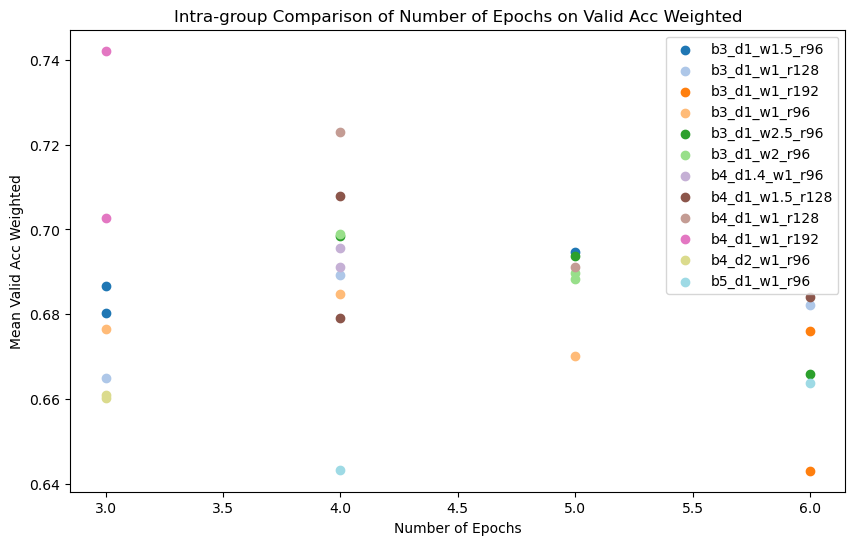

In [20]:
# Group the DataFrame by the "name" column
grouped = df.groupby("name")

# Create a list of unique colors for each group
#colors = plt.cm.viridis(np.linspace(0, 1, ))
distinct_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
num_colors = len(grouped)
colors = plt.cm.get_cmap("tab20", num_colors)
colors(range(num_colors))

# Initialize a plot
plt.figure(figsize=(10, 6))

# Iterate through each group
for (name, group_df), color in zip(grouped, colors(range(num_colors))):
    # Check if there is more than one row in the group (i.e., multiple epochs)
    if len(group_df) > 1:
        # Calculate the mean of the final valid_acc_weighted values
        valid_acc_weighted = group_df["valid_acc_weighted"].to_list()
        valid_acc_weighted = [acc[-1] for acc in valid_acc_weighted]

        # Get the number of epochs for this group
        num_epoch = group_df["epochs"].to_list()
        num_epoch = [len(epoch) for epoch in num_epoch]
        
        # Scatter plot with a unique color for each group
        plt.scatter(num_epoch, valid_acc_weighted, label=name, color=color)

# Add labels and legend
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Valid Acc Weighted")
plt.title("Intra-group Comparison of Number of Epochs on Valid Acc Weighted")
plt.legend(loc="best")
plt.show()

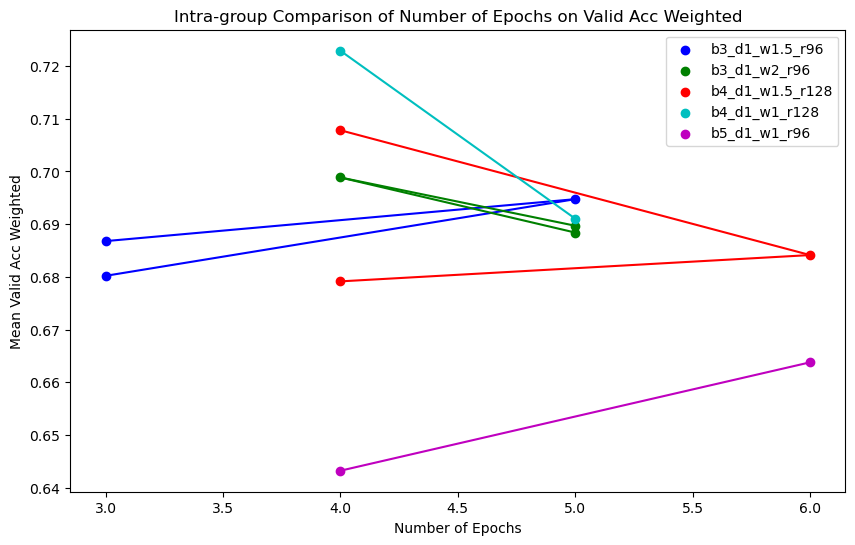

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# Assuming you already have the DataFrame
# df = ...

# Group the DataFrame by the "name" column
grouped = df.groupby("name")

# Initialize a plot
plt.figure(figsize=(10, 6))

# Define a list of distinct colors
distinct_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# Create an iterator for the distinct colors
color_iterator = itertools.cycle(distinct_colors)

# Iterate through each group
for name, group_df in grouped:
    # Check if there is more than one row in the group (i.e., multiple epochs)
    if len(group_df) > 1:
        # Get the number of epochs for each run in the group
        num_epochs_list = group_df["epochs"].tolist()
        
        # Get the valid_acc_weighted for each run in the group
        valid_acc_weighted_list = group_df["valid_acc_weighted"].tolist()
        
        # Check if the len(epochs) is different for the two runs in the group
        if len(set(len(epoch) for epoch in num_epochs_list)) == 2:
            # Get a distinct color for this group
            color = next(color_iterator)
            
            # Scatter plot for each run with the group's color
            for i, (num_epoch, valid_acc_weighted) in enumerate(zip(num_epochs_list, valid_acc_weighted_list)):
                # Calculate the mean of the final valid_acc_weighted values
                final_valid_acc_weighted = valid_acc_weighted[-1]
                
                # Plot the point with the group's color
                plt.scatter(len(num_epoch), final_valid_acc_weighted, label=name if i == 0 else "", color=color)
                
                # Connect the points with lines
                if i > 0:
                    plt.plot([len(num_epochs_list[0]), len(num_epochs_list[1])],
                             [valid_acc_weighted_list[0][-1], final_valid_acc_weighted],
                             color=color)

# Add labels and legend
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Valid Acc Weighted")
plt.title("Intra-group Comparison of Number of Epochs on Valid Acc Weighted")
plt.legend(loc="best")
plt.show()


# b4_d1_w1.5_r128
# b3_d1_w2_r96

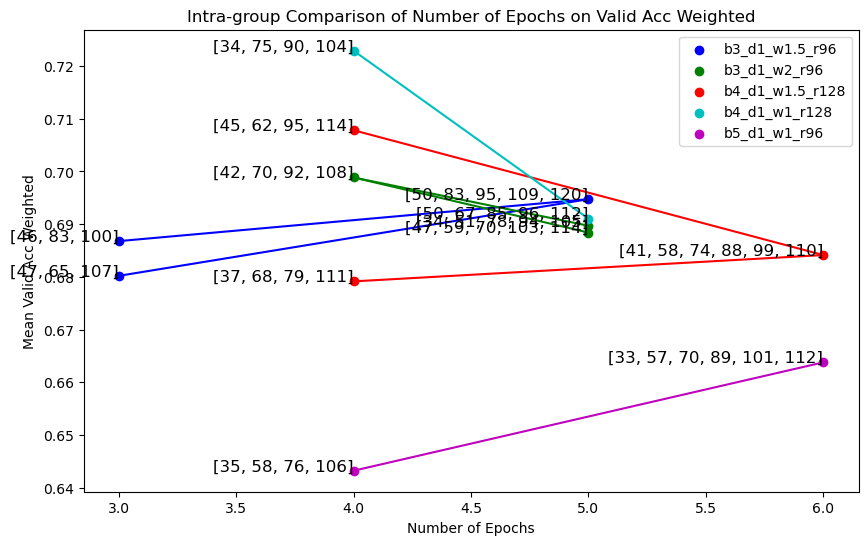

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# Assuming you already have the DataFrame
# df = ...

# Group the DataFrame by the "name" column
grouped = df.groupby("name")

# Initialize a plot
plt.figure(figsize=(10, 6))

# Define a list of distinct colors
distinct_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# Create an iterator for the distinct colors
color_iterator = itertools.cycle(distinct_colors)

# Iterate through each group
for name, group_df in grouped:
    # Check if there is more than one row in the group (i.e., multiple epochs)
    if len(group_df) > 1:
        # Get the number of epochs for each run in the group
        num_epochs_list = group_df["epochs"].tolist()
        
        # Get the valid_acc_weighted for each run in the group
        valid_acc_weighted_list = group_df["valid_acc_weighted"].tolist()
        
        # Check if the len(epochs) is different for the two runs in the group
        if len(set(len(epoch) for epoch in num_epochs_list)) == 2:
            # Get a distinct color for this group
            color = next(color_iterator)
            
            # Scatter plot for each run with the group's color
            for i, (num_epoch, valid_acc_weighted) in enumerate(zip(num_epochs_list, valid_acc_weighted_list)):
                # Calculate the mean of the final valid_acc_weighted values
                final_valid_acc_weighted = valid_acc_weighted[-1]
                
                # Get the number of epochs for this run
                num_epoch_label = len(num_epoch)
                
                # Plot the point with the group's color
                plt.scatter(num_epoch_label, final_valid_acc_weighted, label=name if i == 0 else "", color=color)
                
                # Connect the points with lines
                if i > 0:
                    plt.plot([len(num_epochs_list[0]), len(num_epochs_list[1])],
                             [valid_acc_weighted_list[0][-1], final_valid_acc_weighted],
                             color=color)
                
                # Add a label for the number of epochs
                plt.text(num_epoch_label, final_valid_acc_weighted, str(num_epoch), fontsize=12, ha='right')

# Add labels and legend
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Valid Acc Weighted")
plt.title("Intra-group Comparison of Number of Epochs on Valid Acc Weighted")
plt.legend(loc="best")
plt.show()

# [35,75,90,105]